In [11]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

**Load the Dataset**

In [4]:
df_cluster = pd.read_csv("Crop_recommendation.csv")

print("Dataset Shape:", df_cluster.shape)
display(df_cluster)

Dataset Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


**Dataset information**

In [6]:
print("Dataset Information:")
df_cluster.info()
print("\nMissing Values:")
print(df_cluster.isnull().sum())
print("\nDuplicate Rows:")
print(df_cluster.duplicated().sum())
print("\nDescribe:")
print(df_cluster.describe())
df_cluster = df_cluster.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_cluster.shape)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows:
0

Describe:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091 

**Select Features for Clustering**

In [7]:
cluster_features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

X_cluster = df_cluster[cluster_features]

print("Features used for clustering:")
display(X_cluster.head())

Features used for clustering:


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


**Standardization**

In [8]:
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)
print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (2200, 7)


**Exploratory Correlation Heatmap**

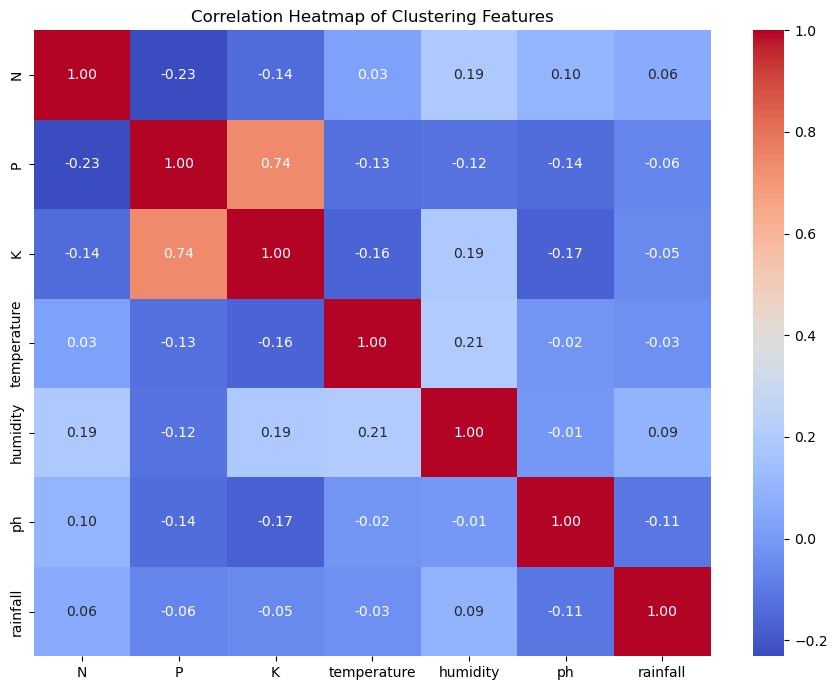

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    X_cluster.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Clustering Features")
plt.tight_layout()
plt.show()

The heatmap indicates that most clustering features have weak or negligible linear correlations, suggesting good feature diversity. The notable exception is the strong positive correlation between phosphorus (P) and potassium (K), with a correlation of 0.74. Therefore, P and K contain some overlapping information, while the other environmental and soil features contribute relatively independent information to the clustering process.

**K-Means — Finding Optimal K**

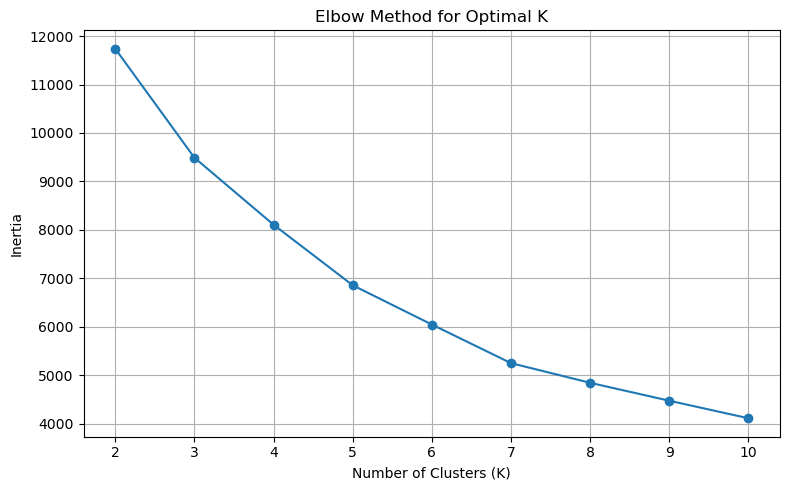

In [12]:
warnings.filterwarnings("ignore")
inertia_values = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(K_range)
plt.grid(True)

plt.tight_layout()
plt.show()

The Elbow Method suggests that K = 5 is a suitable choice for the number of clusters. At this point, the reduction in inertia starts becoming less significant, indicating that increasing the number of clusters beyond 5 provides diminishing improvement in within-cluster compactness.

**Train K-Means**

In [15]:
OPTIMAL_K = 5
kmeans_model = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

df_cluster["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster counts:")
print(df_cluster["KMeans_Cluster"].value_counts().sort_index())

K-Means cluster counts:
KMeans_Cluster
0    627
1    558
2    580
3    200
4    235
Name: count, dtype: int64


**K-Means Evaluation**

In [16]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

print("K-Means Evaluation")
print("----------------------------")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Davies-Bouldin Index:", round(kmeans_db, 4))
print("Calinski-Harabasz Index:", round(kmeans_ch, 4))

K-Means Evaluation
----------------------------
Silhouette Score: 0.2925
Davies-Bouldin Index: 1.2803
Calinski-Harabasz Index: 683.8184
